# Deep Learning Competition 3

 ## Team 13
113062644  
113501525  
112078502  


Report should contain :  
1. Pick 5 descriptions from testing data and generate 5 images with different noise z respectively.
2. Models you tried during competition. Briefly describe the main idea of the model and the reason you chose that model.
3. List the experiment you did. For example, data augmentation, hyper-parameters tuning, architecture tuning, optimizer tuning, and so on.
4. Anything worth mentioning. For example, how to pre-train the model.

https://www.kaggle.com/competitions/2025-datalab-cup-3-reverse-image-caption

# 1. Inference images and generate 5 images with different noise

Use subjective human evaluation of the generated images in order to evaluate the quality of generated images thoroughly. Basically, the default score is based on private leaderboard of competition. We will modify the score only if quality of generated images are much better or worse than the score. Therefore, instead of being the winner in the competition, you have to make sure the generated images have reasonable quality. (30%)

我們最後submit的版本是noise 0，但後來發現我們實測的Noise 3版本的分數score更高(Private score : 0.44228, Public score: 0.44464)

針對Noise 0 (submit) 的照片中，
- 1st row 非常準確，他有抓到"star shape(data寫started應該是spelling error)"，長出來得花也是五星形超強，不只花的圖片很好也完全符合文字
- 2nd row 的圖片也有抓到"many patals", "many stamen with yellow anther at the center"
- 3rd row 有抓到oval shapped !! 而且長得也很好看
- 4th row 完全就是個有質感的紫色花花圖
- 5th row 有對應到文字中的"curve around the edges"，那種邊邊稍微捲捲翹翹的，而且超像會去花店買的花

整體產出來的圖片實在太像真實世界的花，品質良好，且sample中都有align到text ！ (Our generated images does not only have "reasonable quailty" but "very realistic and excellent" quality ^_^)，而且其他noise的sample表現也都相當不錯


Noise 0 --- Private score : 0.46180  , Public score: 0.47773 
Noise 3 ---Private score : 0.44228  , Public score: 0.44464 


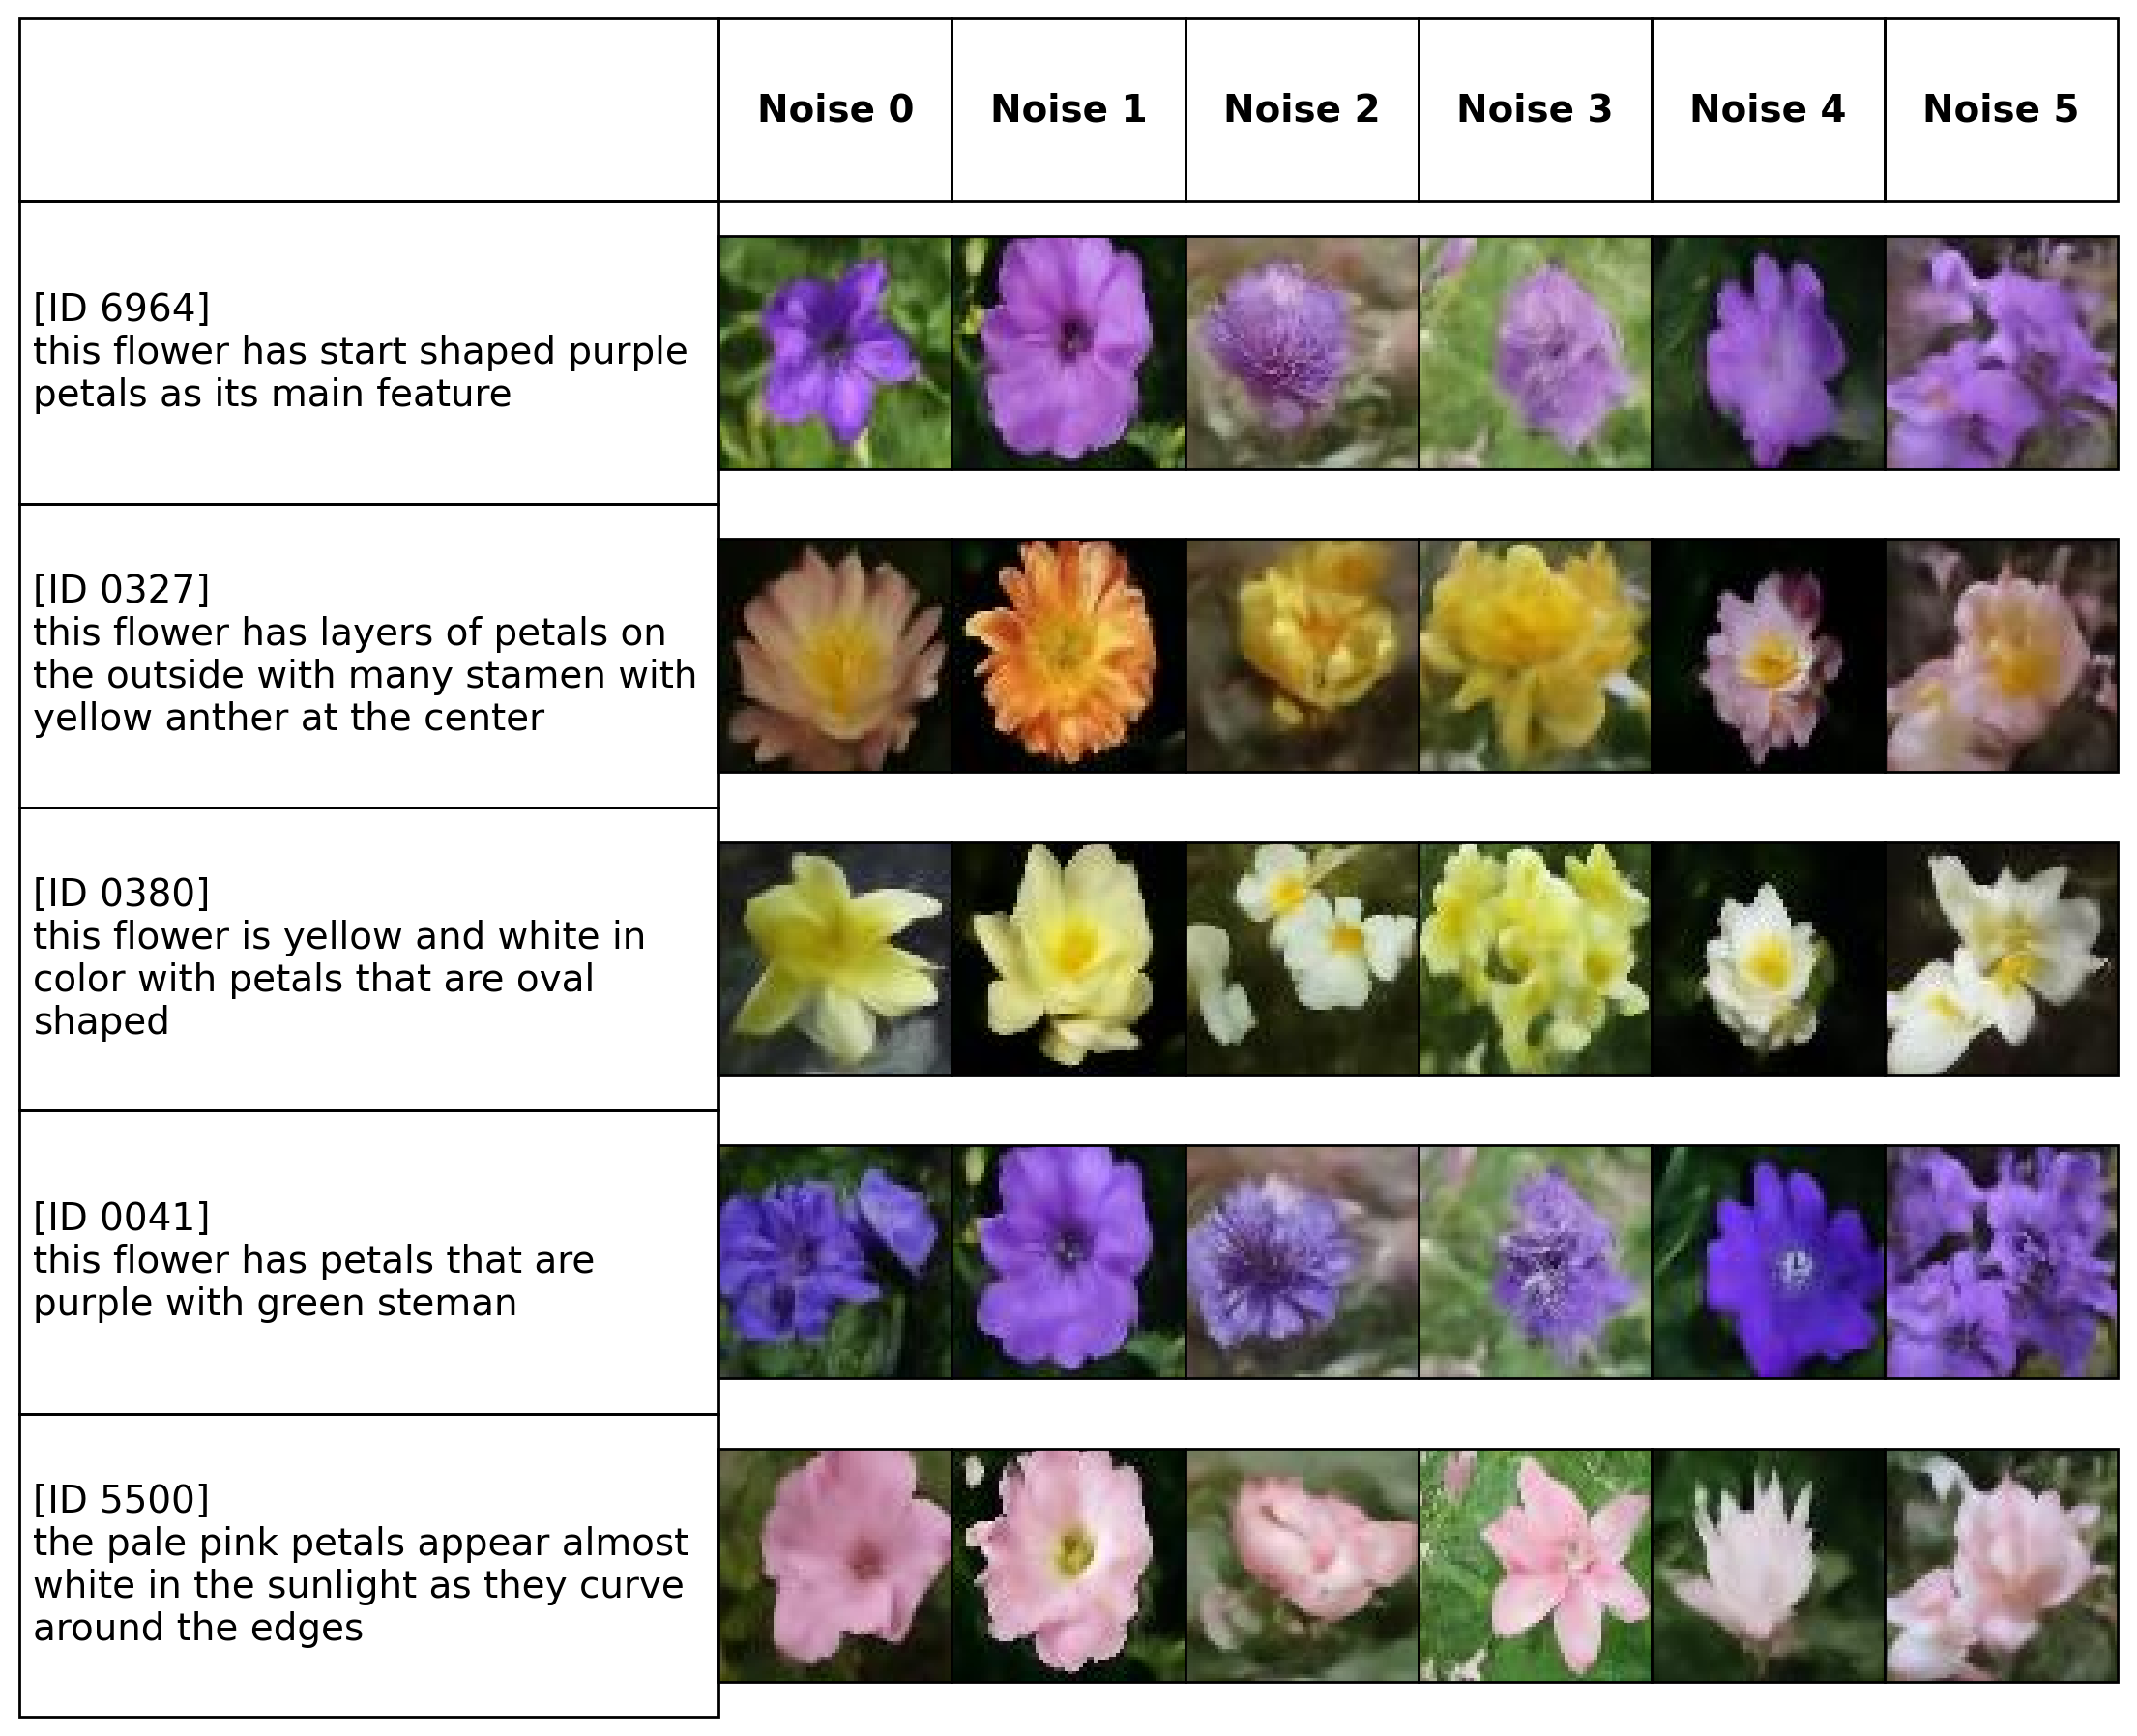

In [1]:
from IPython.display import Image, display
print("Noise 0 --- Private score : 0.46180  , Public score: 0.47773 ")
print("Noise 3 ---Private score : 0.44228  , Public score: 0.44464 ")
display(Image(filename="./image_report_final.png"))

# 2. Models you tried during competition. Briefly describe the main idea of the model and the reason you chose that model.

* 因為前一陣子stable diffusion產圖的能力非常驚豔，因此想使用和stable diffusion一樣的方式將圖片壓到latent space並且和文字的feature concate後做cross attention，雖然一開始可以產生形狀像花的圖片，但是不管怎麼訓練都很模糊，後來將訓練資料拿來測試encoder和decoder後發現可能是VAE沒有寫好導致一些高頻率的feature丟失，會讓diffusion產生的圖片有上限在。
* 後來決定直接修改DDIM，並且保留文字feature加上cross attention的方式，在pixel level做denoise，發現可以較清楚的產生花的圖片後決定採用這個方式。


# 3 List the experiment you did. For example, data augmentation, hyper-parameters tuning, architecture tuning, optimizer tuning, and so on.

## 3-1 Data Augmentation

* 助教給的範例中，每個image只隨機挑10個caption的其中一個來做使用，我們把一個image的所有caption都抓進來，另外在generate的時候套用```training_data_generator```，並repeat 3次 -> 最終的training data增加量約是原本的 30倍！
* 針對每張照片的處理(```training_data_generator```)
    * 稍微把圖片變大(約10%)之後再random crop-> 增加圖片多樣性
    * 有random horizontal flip
    * clip by value 資料增強後最後一道安全檢查保證每個 RGB 像素值仍落在合法範圍 [0,1]


## 3-2 Hyper-parameter tuning

* EMA decay在設為0.9時產生的圖片還是很多雜訊，將EMA decay慢慢調高時發現模型產生的圖片較乾淨，最後則將EMA decay設為0.9995
* 在做stable diffusion時有試過timestep 200~1000的實驗，發現在推論時timestep較低的話圖片會較乾淨、噪點較少，但細節也較timestep高的結果少，權衡之下後來是用timestep較低的設定
* 除了原本的```diff_noise```想辦法把noise預測準，有試著再多加```total_noise```，讓多注意反推回來乾淨的圖像不像真的花(因為 VGG/ inception evaluate跑得有看圖片相似度 cosine distance)，但後來發現DDIM產出來的圖大部分都非常像花了，加上之後效果也沒有到很好

## 3-3 architecture tuning
* 一開始在做stable diffusion時，unet的dimension設定為64，訓練出來產生的圖片雜訊非常多，推測是因為訓練資料量對這個設定來說不夠，看不出來花的形狀，後來改成用32後則可以生成出花的輪廓。
* 一開始將文字feature加入模型是用concate的方式，基本上產生的圖片敘述只有顏色勉強能對的上，後來採用在每個down,up stage加上cross attention後可以讓產生的圖片較能符合文字敘述。
* 呈上，使用cross attention的重要性，特別適用在 text-to-image，token 與影像空間位置之間的動態對齊關係，使模型能在不同解析度與不同生成階段根據文字內容調整影像結構與細節。相較於單純的 feature concatenation，cross-attention 提供更細緻且具語意意義的條件控制，因此能顯著提升生成圖片與文字描述的一致性。

## 3-4 optimizer tuning
* 一開始我們直接以固定初始 learning rate 進行訓練，參考一般 AdamW / diffusion 設定，只搭配簡單的 learning rate decay。觀察前幾個 epoch 發現 loss 波動較大，模型收斂速度與穩定性也較差。

* 後來我們發現diffusion model常會採用learning rate warm-up，讓學習率從較小值逐步成長至目標 lr，可以在訓練前期有效抑制梯度震盪，使 loss 曲線更平滑。經過實驗後發現確實使Kaggle分數有所降低。



# 4. Anything worth mentioning. For example, how to pre-train the model.

## 4.1 Text-encoder
我們嘗試了三種不同text encoder的方法

- **GloVe 初始方法**  
  一開始用 GloVe + 自行訓練的encoder做條件輸入。但發現在這樣的架構下，Kaggle 分數長期卡在約 **0.5** 附近，文字與影像的對齊度有限，因此我們認為是GloVe能力不足。

- **改用 CLIP ViT-B/32**  
  經過搜尋資料後，我們發現目前主流的diffusion model通常都是搭配Clip，因此改採用pre-trained的 **CLIP ViT-B/32 text encoder**。
  CLIP 具備更強的文圖對齊能力，讓模型更容易生成與 caption 一致的圖像，Kaggle分數成功降至0.48左右。
  當load pre-train weight的clip時，他的model已經很精準的train出所有包含像是that, is 這些原本需要被word2vec處理掉的東西，所以直接餵原始的text sentence即可。

- **加入 Classifier-Free Guidance（CFG）**  
  進一步在 CLIP 條件上加入 CFG，訓練時隨機 drop 掉部份條件、推論時用condition/uncodition兩種預測做加權。  
  CFG 強化模型對文字條件的依賴，提升 text–image alignment，使最終分數成功下降到最終的0.46左右，通過TA80門檻。

- **更大型的CLIP**  
  文獻與主流實作多採用更大型的 CLIP模型作為text encoder，例如 **CLIP ViT-L/14**、**OpenCLIP ViT-H/14** 等，以獲得更強的語意表徵與文圖對齊能力。由於本次競賽時間以及一些環境問題，我們沒有機會測試這些更大型的 CLIP，有機會進一步優化結果。


## 4.2 Impact of initial noise
因為我們在寫Report時，才有多跑不同的initial noise去看結果，後來發現intial noise其實對evaluate影響蠻大，針對所有跑出來的score.csv直接平均，可以有0.44 to 0.50的差距，也就是後來我又上傳了一版到kaggle，發現又拿到更好的成績(Private score 從0.46180 -> 0.44228)
但其實從第一點生出來的圖片所判斷，兩者版本產出來的圖片已經品質非常接近也很好！所以其實有點像在骰seed。